# 🧠 EfficientNet-B0 Classification Training (Track B)

**Model**: EfficientNet-B0 + Focal Loss (19 classes)  
**Datasets**: PlantVillage (Corn + Tomato) + Cassava Leaf Disease  

### ⚡ Checkpoint & Resume Strategy
1. Saves checkpoint every epoch to `/kaggle/working/`
2. If session expires → save Output as dataset `effnet-checkpoint`
3. New session → attach `effnet-checkpoint` → set `CHECKPOINT_DATASET` in Cell 2

### 📋 Required Datasets (Add via right sidebar)
- `new-plant-diseases-dataset` (PlantVillage)
- `cassava-leaf-disease-classification`  
- `effnet-checkpoint` (only if resuming)

---
## 📦 Cell 1: Setup & GPU Check

In [1]:
import os, sys, shutil, json, random, gc
from pathlib import Path
from tqdm import tqdm

!pip install -q pydantic-settings python-dotenv albumentations

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader
from torchvision import transforms, datasets, models
from sklearn.metrics import f1_score, classification_report
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

WORKING = '/kaggle/working'
os.chdir(WORKING)

# ── GPU Diagnostic ──
print('='*50)
print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
print(f'CUDA version: {torch.version.cuda}')
print(f'GPU count: {torch.cuda.device_count()}')

if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    for i in range(torch.cuda.device_count()):
        props = torch.cuda.get_device_properties(i)
        print(f'  GPU {i}: {props.name} | {props.total_memory/1024**3:.1f} GB VRAM')
    # Quick GPU test
    x = torch.randn(100, 100, device='cuda')
    print(f'\n✅ GPU test passed — tensor on {x.device}')
    del x
    torch.cuda.empty_cache()
else:
    DEVICE = torch.device('cpu')
    print('❌ NO GPU DETECTED — training will be very slow!')
    print('   Go to Settings → Accelerator → GPU T4')
print('='*50)

print('\n📂 /kaggle/input:')
for d in sorted(os.listdir('/kaggle/input')):
    print(f'  📁 {d}')

PyTorch: 2.10.0+cu128
CUDA available: True
CUDA version: 12.8
GPU count: 2
  GPU 0: Tesla T4 | 14.6 GB VRAM
  GPU 1: Tesla T4 | 14.6 GB VRAM

✅ GPU test passed — tensor on cuda:0

📂 /kaggle/input:
  📁 datasets


---
## 🔧 Cell 2: Configure Paths

In [2]:
# ============================================================
#  👇 UPDATE THESE
# ============================================================
PLANTVILLAGE_NAME  = 'new-plant-diseases-dataset'
CASSAVA_NAME       = 'cassava-leaf-disease-classification'
CHECKPOINT_DATASET = ''    # SET THIS TO RESUME! e.g. 'effnet-checkpoint'
# ============================================================

PLANTVILLAGE_PATH = os.path.join('/kaggle/input/datasets/vipoooool', PLANTVILLAGE_NAME)
CASSAVA_PATH      = os.path.join('/kaggle/input/datasets/nirmalsankalana', CASSAVA_NAME)

assert os.path.exists(PLANTVILLAGE_PATH), f'❌ PlantVillage not found: {PLANTVILLAGE_PATH}'
assert os.path.exists(CASSAVA_PATH), f'❌ Cassava not found: {CASSAVA_PATH}'
print(f'✅ PlantVillage: {PLANTVILLAGE_PATH}')
print(f'✅ Cassava: {CASSAVA_PATH}')

# Check for checkpoint
RESUME_CKPT = None
START_EPOCH = 0
if CHECKPOINT_DATASET:
    ckpt_dir = os.path.join('/kaggle/input', CHECKPOINT_DATASET)
    if os.path.exists(ckpt_dir):
        for fname in ['effnet_checkpoint.pth', 'checkpoint.pth']:
            for root, dirs, files in os.walk(ckpt_dir):
                if fname in files:
                    RESUME_CKPT = os.path.join(root, fname)
                    print(f'✅ Found checkpoint: {RESUME_CKPT}')
                    break
            if RESUME_CKPT: break
    
if RESUME_CKPT:
    print(f'🔄 RESUME MODE')
else:
    print(f'🆕 FRESH START')

✅ PlantVillage: /kaggle/input/datasets/vipoooool/new-plant-diseases-dataset
✅ Cassava: /kaggle/input/datasets/nirmalsankalana/cassava-leaf-disease-classification
🆕 FRESH START


---
## 🔧 Cell 3: Build Unified Dataset
Merges PlantVillage (Corn+Tomato) + Cassava into one folder structure.

In [3]:
UNIFIED_DIR = os.path.join(WORKING, 'unified_cls')

# Skip if already built
if os.path.exists(os.path.join(UNIFIED_DIR, 'train')) and len(os.listdir(os.path.join(UNIFIED_DIR, 'train'))) >= 15:
    print('📂 Unified dataset already exists, skipping rebuild.')
    print(f'   Classes: {sorted(os.listdir(os.path.join(UNIFIED_DIR, "train")))}')
else:
    if os.path.exists(UNIFIED_DIR):
        shutil.rmtree(UNIFIED_DIR)

    # ── PlantVillage: Extract Corn + Tomato ──
    pv_train = None
    for root, dirs, files in os.walk(PLANTVILLAGE_PATH):
        if 'train' in dirs:
            pv_train = os.path.join(root, 'train')
            break
    if pv_train is None:
        pv_train = PLANTVILLAGE_PATH

    pv_val_path = pv_train.replace('train', 'valid')
    pv_val = pv_val_path if os.path.exists(pv_val_path) else None
    
    PV_MAP = {
        'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 'Corn_Cercospora_Leaf_Spot',
        'Corn_(maize)___Common_rust_': 'Corn_Common_Rust',
        'Corn_(maize)___Northern_Leaf_Blight': 'Corn_Northern_Leaf_Blight',
        'Corn_(maize)___healthy': 'Corn_Healthy',
        'Tomato___Bacterial_spot': 'Tomato_Bacterial_Spot',
        'Tomato___Early_blight': 'Tomato_Early_Blight',
        'Tomato___Late_blight': 'Tomato_Late_Blight',
        'Tomato___Leaf_Mold': 'Tomato_Leaf_Mold',
        'Tomato___Septoria_leaf_spot': 'Tomato_Septoria_Leaf_Spot',
        'Tomato___Spider_mites Two-spotted_spider_mite': 'Tomato_Spider_Mites',
        'Tomato___Target_Spot': 'Tomato_Target_Spot',
        'Tomato___Tomato_Yellow_Leaf_Curl_Virus': 'Tomato_Yellow_Leaf_Curl_Virus',
        'Tomato___Tomato_mosaic_virus': 'Tomato_Mosaic_Virus',
        'Tomato___healthy': 'Tomato_Healthy',
    }

    def copy_pv(src_dir, split):
        if not src_dir or not os.path.exists(src_dir): return 0
        n = 0
        for orig, unified in PV_MAP.items():
            src = os.path.join(src_dir, orig)
            if not os.path.exists(src): continue
            dst = os.path.join(UNIFIED_DIR, split, unified)
            os.makedirs(dst, exist_ok=True)
            for f in os.listdir(src):
                if f.lower().endswith(('.jpg','.jpeg','.png')):
                    shutil.copy2(os.path.join(src, f), os.path.join(dst, f))
                    n += 1
        return n

    print('🌽🍅 Copying PlantVillage...')
    n1 = copy_pv(pv_train, 'train')
    n2 = copy_pv(pv_val, 'val')
    print(f'   {n1} train + {n2} val')

    # ── Cassava ──
    print('🌿 Processing Cassava...')
    CASSAVA_MAP = {0:'Cassava_Bacterial_Blight', 1:'Cassava_Brown_Streak_Disease',
                   2:'Cassava_Green_Mottle', 3:'Cassava_Mosaic_Disease', 4:'Cassava_Healthy'}

    cassava_images = cassava_csv = None
    for root, dirs, files in os.walk(CASSAVA_PATH):
        if 'train_images' in dirs: cassava_images = os.path.join(root, 'train_images')
        if 'train.csv' in files: cassava_csv = os.path.join(root, 'train.csv')

    if cassava_images and cassava_csv:
        df = pd.read_csv(cassava_csv).sample(frac=1, random_state=42).reset_index(drop=True)
        split_idx = int(len(df) * 0.8)
        for split, sdf in [('train', df[:split_idx]), ('val', df[split_idx:])]:
            for _, row in tqdm(sdf.iterrows(), total=len(sdf), desc=f'Cassava {split}'):
                cls = CASSAVA_MAP[int(row['label'])]
                dst = os.path.join(UNIFIED_DIR, split, cls)
                os.makedirs(dst, exist_ok=True)
                src = os.path.join(cassava_images, row['image_id'])
                if os.path.exists(src):
                    shutil.copy2(src, os.path.join(dst, row['image_id']))
        print(f'   {split_idx} train + {len(df)-split_idx} val')

    # Summary
    print('\n📊 Final Dataset:')
    for split in ['train', 'val']:
        sp = os.path.join(UNIFIED_DIR, split)
        if os.path.exists(sp):
            classes = sorted(os.listdir(sp))
            total = sum(len(os.listdir(os.path.join(sp, c))) for c in classes)
            print(f'   {split}: {len(classes)} classes, {total:,} images')
            for c in classes:
                print(f'      {c}: {len(os.listdir(os.path.join(sp, c)))}')

🌽🍅 Copying PlantVillage...
   25661 train + 6414 val
🌿 Processing Cassava...

📊 Final Dataset:
   train: 14 classes, 25,661 images
      Corn_Cercospora_Leaf_Spot: 1642
      Corn_Common_Rust: 1907
      Corn_Healthy: 1859
      Corn_Northern_Leaf_Blight: 1908
      Tomato_Bacterial_Spot: 1702
      Tomato_Early_Blight: 1920
      Tomato_Healthy: 1926
      Tomato_Late_Blight: 1851
      Tomato_Leaf_Mold: 1882
      Tomato_Mosaic_Virus: 1790
      Tomato_Septoria_Leaf_Spot: 1745
      Tomato_Spider_Mites: 1741
      Tomato_Target_Spot: 1827
      Tomato_Yellow_Leaf_Curl_Virus: 1961
   val: 14 classes, 6,414 images
      Corn_Cercospora_Leaf_Spot: 410
      Corn_Common_Rust: 477
      Corn_Healthy: 465
      Corn_Northern_Leaf_Blight: 477
      Tomato_Bacterial_Spot: 425
      Tomato_Early_Blight: 480
      Tomato_Healthy: 481
      Tomato_Late_Blight: 463
      Tomato_Leaf_Mold: 470
      Tomato_Mosaic_Virus: 448
      Tomato_Septoria_Leaf_Spot: 436
      Tomato_Spider_Mites: 435
     

---
## 🚀 Cell 4: Build Model & DataLoaders (GPU-Optimized)

In [4]:
# ── Force GPU setup (self-contained, doesn't depend on Cell 1) ──
assert torch.cuda.is_available(), '❌ GPU NOT AVAILABLE! Go to Settings → Accelerator → GPU T4'
DEVICE = torch.device('cuda')
torch.backends.cudnn.benchmark = True  # Optimizes convolution algorithms for fixed input size
print(f'🖥️ Device: {DEVICE} ({torch.cuda.get_device_name(0)})')

# ── Hyperparameters ──
IMG_SIZE     = 224
BATCH_SIZE   = 32       # Reduced to fix RAM crash
TOTAL_EPOCHS = 11
LR           = 1e-3
NUM_WORKERS  = 0

MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomVerticalFlip(0.3),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

train_dataset = datasets.ImageFolder(os.path.join(UNIFIED_DIR, 'train'), transform=train_transform)
val_dataset   = datasets.ImageFolder(os.path.join(UNIFIED_DIR, 'val'),   transform=val_transform)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=False,
        # Pre-load 3 batches per worker → GPU never starved
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=False,
)

NUM_CLASSES = len(train_dataset.classes)
CLASS_NAMES = train_dataset.classes
print(f'\n📊 Classes ({NUM_CLASSES}): {CLASS_NAMES}')
print(f'Train: {len(train_dataset):,} | Val: {len(val_dataset):,}')

# ── Standard Cross Entropy Loss ──
# (More stable than Focal Loss for simple training)

# ── Build Model → GPU ──
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, NUM_CLASSES)

# 🔥 Enforcing single GPU to prevent DataParallel memory duplicate crashes on Kaggle.
# model = nn.DataParallel(model)  <- Removed

model = model.to(DEVICE)
criterion = nn.CrossEntropyLoss().to(DEVICE)  # Loss on GPU

optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)
scaler = torch.amp.GradScaler('cuda')

# ── Verify model is ACTUALLY on GPU ──
test_param = next(model.parameters())
print(f'\n✅ Model device: {test_param.device}')
print(f'✅ Model params: {sum(p.numel() for p in model.parameters()):,}')
alloc = torch.cuda.memory_allocated() / 1024**2
print(f'✅ GPU memory used: {alloc:.0f} MB')

# ── Load checkpoint if resuming ──
history = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[], 'val_f1':[]}
best_acc = 0.0

if RESUME_CKPT:
    ckpt = torch.load(RESUME_CKPT, map_location=DEVICE)
    state_dict = ckpt.get('model_state_dict', ckpt)
    try:
        m = model.module if hasattr(model, 'module') else model
        m.load_state_dict(state_dict)
    except:
        model.load_state_dict(state_dict)
    if 'optimizer_state_dict' in ckpt: optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    if 'scheduler_state_dict' in ckpt: scheduler.load_state_dict(ckpt['scheduler_state_dict'])
    if 'scaler_state_dict' in ckpt: scaler.load_state_dict(ckpt['scaler_state_dict'])
    START_EPOCH = ckpt.get('epoch', 0)
    best_acc = ckpt.get('best_acc', 0.0)
    history = ckpt.get('history', history)
    print(f'\n🔄 Resumed from epoch {START_EPOCH}, best_acc={best_acc:.2f}%')

print(f'\n🚀 Ready: epochs {START_EPOCH+1}→{TOTAL_EPOCHS} | batch={BATCH_SIZE} | device={DEVICE}')

🖥️ Device: cuda (Tesla T4)

📊 Classes (14): ['Corn_Cercospora_Leaf_Spot', 'Corn_Common_Rust', 'Corn_Healthy', 'Corn_Northern_Leaf_Blight', 'Tomato_Bacterial_Spot', 'Tomato_Early_Blight', 'Tomato_Healthy', 'Tomato_Late_Blight', 'Tomato_Leaf_Mold', 'Tomato_Mosaic_Virus', 'Tomato_Septoria_Leaf_Spot', 'Tomato_Spider_Mites', 'Tomato_Target_Spot', 'Tomato_Yellow_Leaf_Curl_Virus']
Train: 25,661 | Val: 6,414
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 139MB/s]



✅ Model device: cuda:0
✅ Model params: 4,025,482
✅ GPU memory used: 16 MB

🚀 Ready: epochs 1→11 | batch=32 | device=cuda


---
## 🔥 Cell 5: Train (GPU-Accelerated)

In [5]:
BEST_PATH = os.path.join(WORKING, 'best_efficientnet.pth')
CKPT_PATH = os.path.join(WORKING, 'effnet_checkpoint.pth')

for epoch in range(START_EPOCH, TOTAL_EPOCHS):
    # ── Train ──
    model.train()
    rloss, correct, total = 0.0, 0, 0
    pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{TOTAL_EPOCHS} [Train]')
    for images, labels in pbar:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)  # Faster than zero_grad()
        with torch.amp.autocast('cuda'):       # FP16 forward pass
            out = model(images)
            loss = criterion(out, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        # scheduler.step() moved to epoch end
        rloss += loss.item()*images.size(0)
        _, preds = torch.max(out, 1)
        correct += (preds==labels).sum().item()
        total += labels.size(0)
        pbar.set_postfix(loss=f'{rloss/total:.4f}', acc=f'{100*correct/total:.1f}%',
                         gpu=f'{torch.cuda.memory_allocated()/1024**2:.0f}MB')
    train_loss = rloss/total
    train_acc = 100*correct/total

    # ── Validate ──
    model.eval()
    vloss, correct, total = 0.0, 0, 0
    all_p, all_l = [], []
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f'Epoch {epoch+1}/{TOTAL_EPOCHS} [Val]'):
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)
            with torch.amp.autocast('cuda'):
                out = model(images)
                loss = criterion(out, labels)
            vloss += loss.item()*images.size(0)
            _, preds = torch.max(out, 1)
            correct += (preds==labels).sum().item()
            total += labels.size(0)
            all_p.extend(preds.cpu().numpy())
            all_l.extend(labels.cpu().numpy())
    val_loss = vloss/total
    val_acc = 100*correct/total
    val_f1 = f1_score(all_l, all_p, average='weighted')

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    gpu_mem = torch.cuda.max_memory_allocated()/1024**2
    print(f'  Train: loss={train_loss:.4f} acc={train_acc:.2f}%')
    print(f'  Val:   loss={val_loss:.4f} acc={val_acc:.2f}% f1={val_f1:.4f} | GPU peak: {gpu_mem:.0f}MB')

    scheduler.step(val_acc)  # Step scheduler based on validation accuracy

    # Save best
    if val_acc > best_acc:
        best_acc = val_acc
        sd = model.module.state_dict() if hasattr(model, 'module') else model.state_dict()
        torch.save(sd, BEST_PATH)
        print(f'  🏆 New best! {best_acc:.2f}%')

    # Save checkpoint
    sd = model.module.state_dict() if hasattr(model, 'module') else model.state_dict()
    torch.save({
        'epoch': epoch + 1,
        'model_state_dict': sd,
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'scaler_state_dict': scaler.state_dict(),
        'best_acc': best_acc,
        'history': history,
    }, CKPT_PATH)
    print(f'  💾 Checkpoint saved (epoch {epoch+1})')
    # Manual GC to prevent Memory Leak across epochs
    import gc
    gc.collect()
    torch.cuda.empty_cache()

print(f'\n🎉 Done! Best accuracy: {best_acc:.2f}%')
print(f'Peak GPU memory: {torch.cuda.max_memory_allocated()/1024**3:.2f} GB')

Epoch 1/11 [Val]: 100%|██████████| 201/201 [00:26<00:00,  7.67it/s]


  Train: loss=0.2476 acc=92.16%
  Val:   loss=0.0832 acc=97.41% f1=0.9741 | GPU peak: 2330MB
  🏆 New best! 97.41%
  💾 Checkpoint saved (epoch 1)


Epoch 2/11 [Val]: 100%|██████████| 201/201 [00:21<00:00,  9.43it/s]


  Train: loss=0.1168 acc=96.25%
  Val:   loss=0.0462 acc=98.49% f1=0.9848 | GPU peak: 2330MB
  🏆 New best! 98.49%
  💾 Checkpoint saved (epoch 2)


Epoch 3/11 [Val]: 100%|██████████| 201/201 [00:21<00:00,  9.43it/s]


...

  Train: loss=0.0462 acc=98.54%
  Val:   loss=0.0570 acc=97.99% f1=0.9800 | GPU peak: 2330MB
  💾 Checkpoint saved (epoch 9)


Epoch 10/11 [Val]: 100%|██████████| 201/201 [00:20<00:00,  9.70it/s]


  Train: loss=0.0494 acc=98.33%
  Val:   loss=0.1375 acc=95.85% f1=0.9573 | GPU peak: 2330MB
  💾 Checkpoint saved (epoch 10)


Epoch 11/11 [Val]: 100%|██████████| 201/201 [00:20<00:00,  9.78it/s]


  Train: loss=0.0382 acc=98.72%
  Val:   loss=0.0239 acc=99.19% f1=0.9919 | GPU peak: 2330MB
  💾 Checkpoint saved (epoch 11)

🎉 Done! Best accuracy: 99.35%
Peak GPU memory: 2.28 GB


---
## 📊 Cell 6: Training Curves & Report

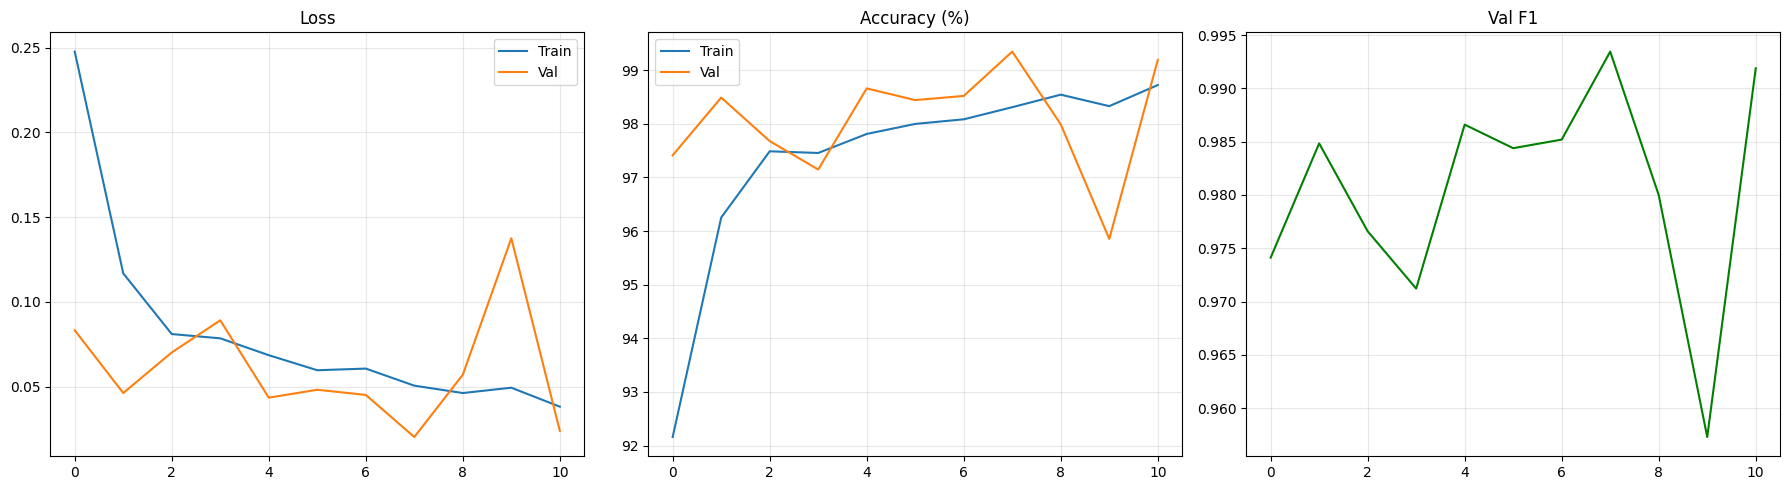


📋 Classification Report:
                               precision    recall  f1-score   support

    Corn_Cercospora_Leaf_Spot       0.98      0.98      0.98       410
             Corn_Common_Rust       0.99      1.00      1.00       477
                 Corn_Healthy       1.00      1.00      1.00       465
    Corn_Northern_Leaf_Blight       0.99      0.98      0.98       477
        Tomato_Bacterial_Spot       1.00      0.97      0.98       425
          Tomato_Early_Blight       0.99      1.00      0.99       480
               Tomato_Healthy       0.99      1.00      1.00       481
           Tomato_Late_Blight       0.99      0.99      0.99       463
             Tomato_Leaf_Mold       1.00      1.00      1.00       470
          Tomato_Mosaic_Virus       1.00      1.00      1.00       448
    Tomato_Septoria_Leaf_Spot       0.98      0.99      0.98       436
          Tomato_Spider_Mites       1.00      1.00      1.00       435
           Tomato_Target_Spot       0.99      0.98

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(history['train_loss'], label='Train'); axes[0].plot(history['val_loss'], label='Val')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(history['train_acc'], label='Train'); axes[1].plot(history['val_acc'], label='Val')
axes[1].set_title('Accuracy (%)'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
axes[2].plot(history['val_f1'], color='green'); axes[2].set_title('Val F1'); axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(WORKING, 'effnet_curves.png'), dpi=150)
plt.show()

print('\n📋 Classification Report:')
print(classification_report(all_l, all_p, target_names=CLASS_NAMES))

---
## 📝 Cell 7: Save Class Mapping

In [7]:
mapping = {
    'num_classes': NUM_CLASSES,
    'class_names': list(CLASS_NAMES),
    'class_to_idx': train_dataset.class_to_idx,
}
with open(os.path.join(WORKING, 'class_mapping.json'), 'w') as f:
    json.dump(mapping, f, indent=2)
print(json.dumps(mapping, indent=2))
print('\n⚠️ Update src/config.py CLASS_NAMES to match this order!')

{
  "num_classes": 14,
  "class_names": [
    "Corn_Cercospora_Leaf_Spot",
    "Corn_Common_Rust",
    "Corn_Healthy",
    "Corn_Northern_Leaf_Blight",
    "Tomato_Bacterial_Spot",
    "Tomato_Early_Blight",
    "Tomato_Healthy",
    "Tomato_Late_Blight",
    "Tomato_Leaf_Mold",
    "Tomato_Mosaic_Virus",
    "Tomato_Septoria_Leaf_Spot",
    "Tomato_Spider_Mites",
    "Tomato_Target_Spot",
    "Tomato_Yellow_Leaf_Curl_Virus"
  ],
  "class_to_idx": {
    "Corn_Cercospora_Leaf_Spot": 0,
    "Corn_Common_Rust": 1,
    "Corn_Healthy": 2,
    "Corn_Northern_Leaf_Blight": 3,
    "Tomato_Bacterial_Spot": 4,
    "Tomato_Early_Blight": 5,
    "Tomato_Healthy": 6,
    "Tomato_Late_Blight": 7,
    "Tomato_Leaf_Mold": 8,
    "Tomato_Mosaic_Virus": 9,
    "Tomato_Septoria_Leaf_Spot": 10,
    "Tomato_Spider_Mites": 11,
    "Tomato_Target_Spot": 12,
    "Tomato_Yellow_Leaf_Curl_Virus": 13
  }
}

⚠️ Update src/config.py CLASS_NAMES to match this order!


---
## 💾 Cell 8: Download & Resume Info

In [8]:
print('📦 Files in /kaggle/working:')
for f in sorted(os.listdir(WORKING)):
    fp = os.path.join(WORKING, f)
    if os.path.isfile(fp):
        mb = os.path.getsize(fp)/(1024*1024)
        print(f'  {f} ({mb:.1f} MB)')

print('\n📥 Download from Output tab.')
print('\n🔄 To resume if session expired:')
print('   1. Output → New Dataset → name: effnet-checkpoint')
print('   2. New notebook → attach effnet-checkpoint + both datasets')
print('   3. Set CHECKPOINT_DATASET = "effnet-checkpoint" in Cell 2')

📦 Files in /kaggle/working:
  __notebook__.ipynb (4.3 MB)
  best_efficientnet.pth (15.6 MB)
  class_mapping.json (0.0 MB)
  effnet_checkpoint.pth (46.5 MB)
  effnet_curves.png (0.1 MB)

📥 Download from Output tab.

🔄 To resume if session expired:
   1. Output → New Dataset → name: effnet-checkpoint
   2. New notebook → attach effnet-checkpoint + both datasets
   3. Set CHECKPOINT_DATASET = "effnet-checkpoint" in Cell 2
